In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
# Загрузка датасета
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MedHouseVal')

# Вывод описания датасета
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

<h2>Первичный осмотр</h2>

In [3]:
# Проверка пропущенных значений
print(X.isnull().sum())
print("Пропуски отсутствуют")

# Обзор данных
print(X.head())
print(y.head())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Пропуски отсутствуют
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


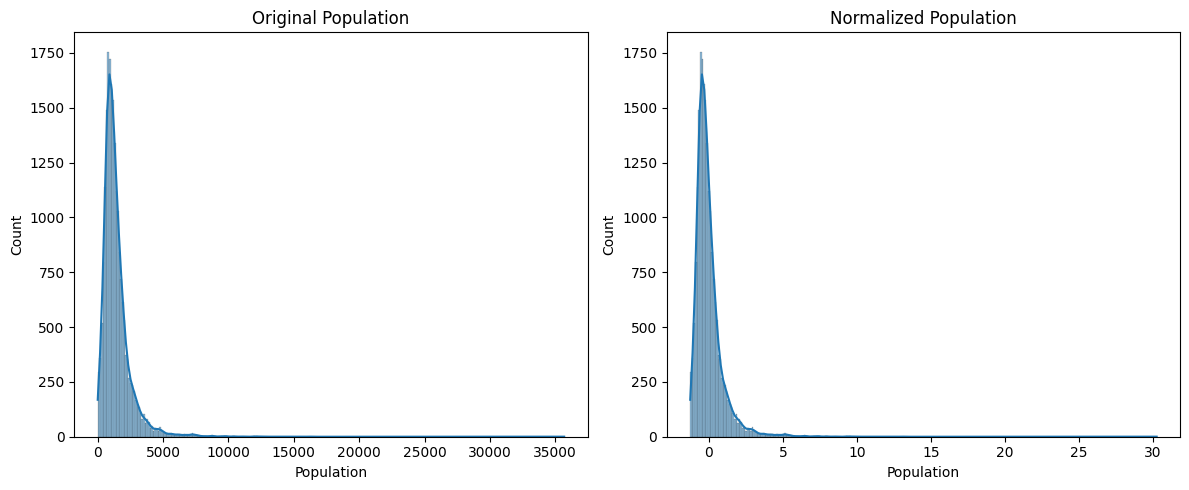

In [ ]:
# Нормализация признака - Population
scaler = StandardScaler()
X_normalized = X.copy()
X_normalized['Population'] = scaler.fit_transform(X_normalized[['Population']])

# Визуализация распределения до/после нормализации
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(X['Population'], ax=axes[0], kde=True)
axes[0].set_title('Original Population')
sns.histplot(X_normalized['Population'], ax=axes[1], kde=True)
axes[1].set_title('Normalized Population')
plt.tight_layout()
plt.show()

In [5]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)
print(f"Размеры выборок: Train - {X_train.shape}, Test - {X_test.shape}")

Размеры выборок: Train - (16512, 8), Test - (4128, 8)


In [6]:
# Создание и обучение модели - Л.регрессии
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Прогнозирование и оценка
y_pred_lr = lr_model.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"R² линейной регрессии: {r2_lr:.4f}")

R² линейной регрессии: 0.5758


In [7]:
#базовое дерево
# Обучение модели
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Оценка производительности
y_pred_dt = dt_model.predict(X_test)
r2_dt = r2_score(y_test, y_pred_dt)
print(f"R² дерева решений: {r2_dt:.4f}")

R² дерева решений: 0.6221


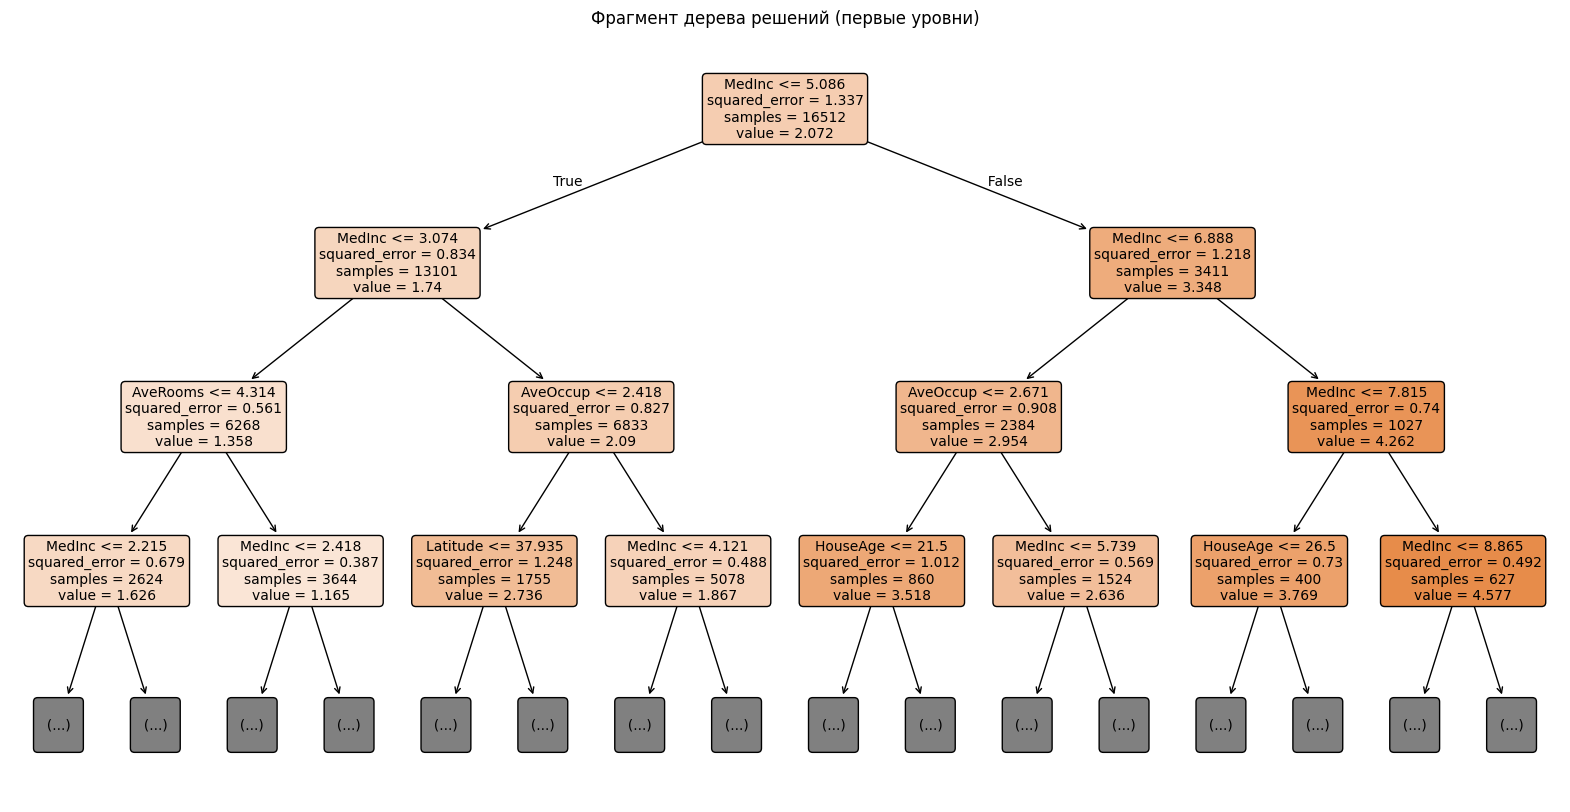

In [9]:
# Визуализация первых 3 уровней
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    max_depth=3,
    feature_names=california.feature_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Фрагмент дерева решений (первые уровни)")
plt.show()

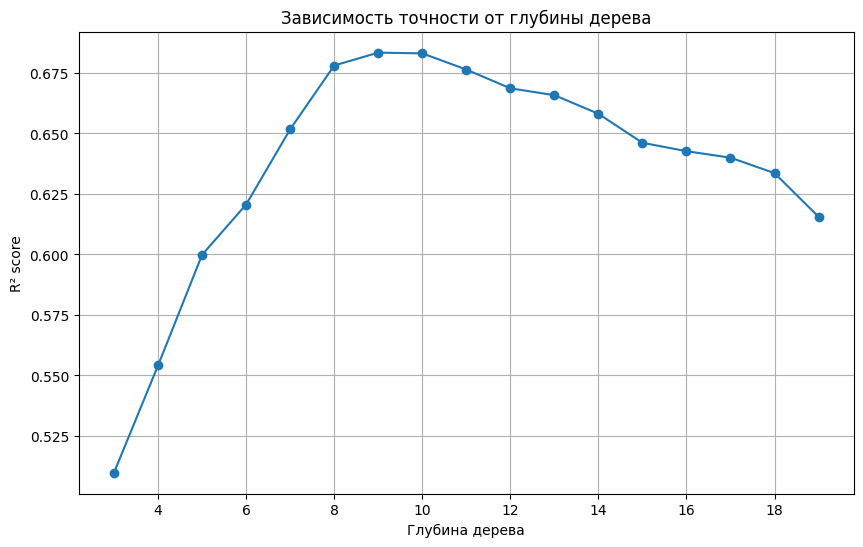

In [10]:
# Подбор оптимальной глубины дерева
max_depths = range(3, 20)
scores = []

for depth in max_depths:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(max_depths, scores, 'o-')
plt.xlabel('Глубина дерева')
plt.ylabel('R² score')
plt.title('Зависимость точности от глубины дерева')
plt.grid(True)
plt.show()

In [12]:
# Оптимизация min_samples_split
best_score = 0
best_params = {}

for min_split in [2, 5, 10, 20]:
    model = DecisionTreeRegressor(
        max_depth=8, 
        min_samples_split=min_split,
        random_state=42
    )
    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)
    if score > best_score:
        best_score = score
        best_params = {'min_samples_split': min_split}

print(f"Оптимальные параметры: {best_params}, R²: {best_score:.4f}")


Оптимальные параметры: {'min_samples_split': 20}, R²: 0.6803


In [13]:
optimized_dt = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=10,
    random_state=42
)
optimized_dt.fit(X_train, y_train)
final_r2 = optimized_dt.score(X_test, y_test)
print(f"Оптимизированное дерево решений R²: {final_r2:.4f}")

Оптимизированное дерево решений R²: 0.6788


<p>Сравнение моделей:</p>
- Линейная регрессия показала наихудший результат из-за нелинейных зависимостей в данных.
- Дерево решений продемонстрировало лучшую производительность после оптимизации гиперпараметров.

<p>Комментарии:</p>
- Деревья решений  
  <p>Плюсы:  </p>
  <p>- Интерпретируемость и визуализация  </p>
  <p>- выбор признаков  </p>
  <p>- Работа с нелинейными зависимостями  </p>
  <p>Минусы:  </p>
  <p>- Склонность к переобучению  </p>
  <p>- Чувствительность к шумам  </p>
   <p> Применение  : Задачи с нелинейными зависимостями, где важна интерпретируемость.</p>

- Линейная регрессия 
    <p>Плюсы  :  </p>
  <p>- Простота и скорость  </p>
  <p>- Устойчивость к переобучению  </p>
    <p>Минусы  :  </p>
  <p>- Низкая точность на сложных данных  </p>
  <p>- Требование линейности  </p>
   <p> Применение  : Базовое моделирование, где зависимости близки к линейным.</p>
